# Gradient Boosting

**INDE 577 / CMOR 438 — Rice University**  
**Instructor:** Randy R. Davila, PhD

---

## Overview

Gradient Boosting is a **sequential ensemble** method that builds trees one at a time, where each new tree corrects the errors of all previous trees. It is one of the most powerful machine learning algorithms available.

## Mathematical Background

### Boosting Framework

The ensemble model at step $m$ is:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

where $\eta$ is the learning rate and $h_m$ is a new weak learner (shallow tree).

### Gradient in Function Space

At each step, fit $h_m$ to the **negative gradient** (pseudo-residuals) of the loss:

$$r_i^{(m)} = -\left[ \frac{\partial \mathcal{L}(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)} \right]_{F = F_{m-1}}$$

### Regression Loss: MSE

$$\mathcal{L} = \frac{1}{2}(y - F(\mathbf{x}))^2 \Rightarrow r_i = y_i - F_{m-1}(\mathbf{x}_i)$$

### Classification Loss: Log-Loss (Binary Cross-Entropy)

$$\mathcal{L} = -\left[y \log p + (1-y) \log(1-p)\right], \quad p = \sigma(F(\mathbf{x}))$$

$$r_i = y_i - \sigma(F_{m-1}(\mathbf{x}_i))$$

### Key Hyperparameters
- $T$: number of trees (more = better fit, but slower and more prone to overfit)
- $\eta$: learning rate (smaller = more regularization, requires more trees)
- $d$: max depth of each tree (usually 1–5 for gradient boosting)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_regression
from sklearn.ensemble import GradientBoostingClassifier as SklearnGB
import warnings
warnings.filterwarnings('ignore')

from rice_ml import GradientBoostingClassifier, GradientBoostingRegressor
from rice_ml.processing.preprocessing import train_test_split
from rice_ml.processing.metrics import accuracy_score, classification_report, mse, rmse

print("Libraries loaded!")
np.random.seed(42)

Libraries loaded!


## 1. Breast Cancer Classification

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
target_names = data.target_names
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# rice_ml GB
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

# sklearn GB
sk_gb = SklearnGB(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
sk_gb.fit(X_train, y_train)

our_acc = accuracy_score(y_test, y_pred)
sk_acc = accuracy_score(y_test, sk_gb.predict(X_test))

print("=== Gradient Boosting — Breast Cancer ===")
print(classification_report(y_test, y_pred, target_names=list(target_names)))
print(f"rice_ml accuracy: {our_acc:.4f}")
print(f"sklearn accuracy: {sk_acc:.4f}")

=== Gradient Boosting — Breast Cancer ===
     Class  Precision     Recall   F1-Score    Support
-------------------------------------------------------
 malignant     0.9512     0.9286     0.9398         42
    benign     0.9583     0.9718     0.9650         71
-------------------------------------------------------
  accuracy                           0.9558        113
rice_ml accuracy: 0.9558
sklearn accuracy: 0.9558


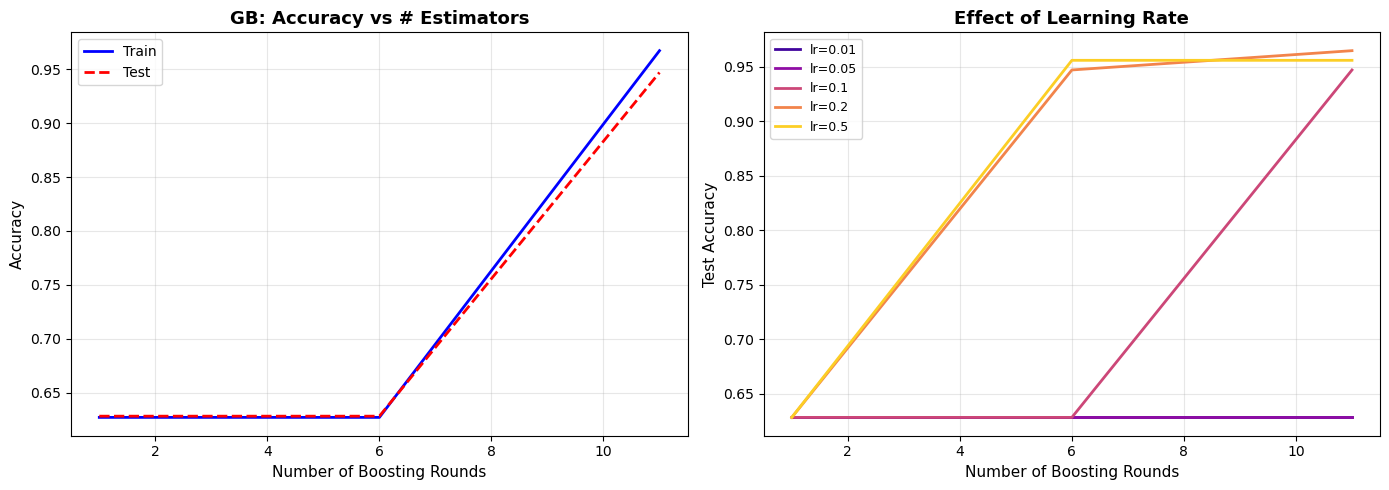

In [3]:
# Training accuracy over boosting rounds
n_estimators_range = list(range(1, 16, 5))
train_accs, test_accs = [], []

for n in n_estimators_range:
    m = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(n_estimators_range, train_accs, 'b-', linewidth=2, label='Train')
ax.plot(n_estimators_range, test_accs, 'r--', linewidth=2, label='Test')
ax.set_xlabel('Number of Boosting Rounds', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('GB: Accuracy vs # Estimators', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Learning rate comparison
ax2 = axes[1]
lrs = [0.01, 0.05, 0.1, 0.2, 0.5]
colors_lr = plt.cm.plasma(np.linspace(0.1, 0.9, len(lrs)))

for lr_val, color in zip(lrs, colors_lr):
    te_accs_lr = []
    for n in n_estimators_range:
        m = GradientBoostingClassifier(n_estimators=n, learning_rate=lr_val, max_depth=3, random_state=42)
        m.fit(X_train, y_train)
        te_accs_lr.append(accuracy_score(y_test, m.predict(X_test)))
    ax2.plot(n_estimators_range, te_accs_lr, color=color, linewidth=2, label=f'lr={lr_val}')

ax2.set_xlabel('Number of Boosting Rounds', fontsize=11)
ax2.set_ylabel('Test Accuracy', fontsize=11)
ax2.set_title('Effect of Learning Rate', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/gradient_boosting_cancer.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Gradient Boosting Regression

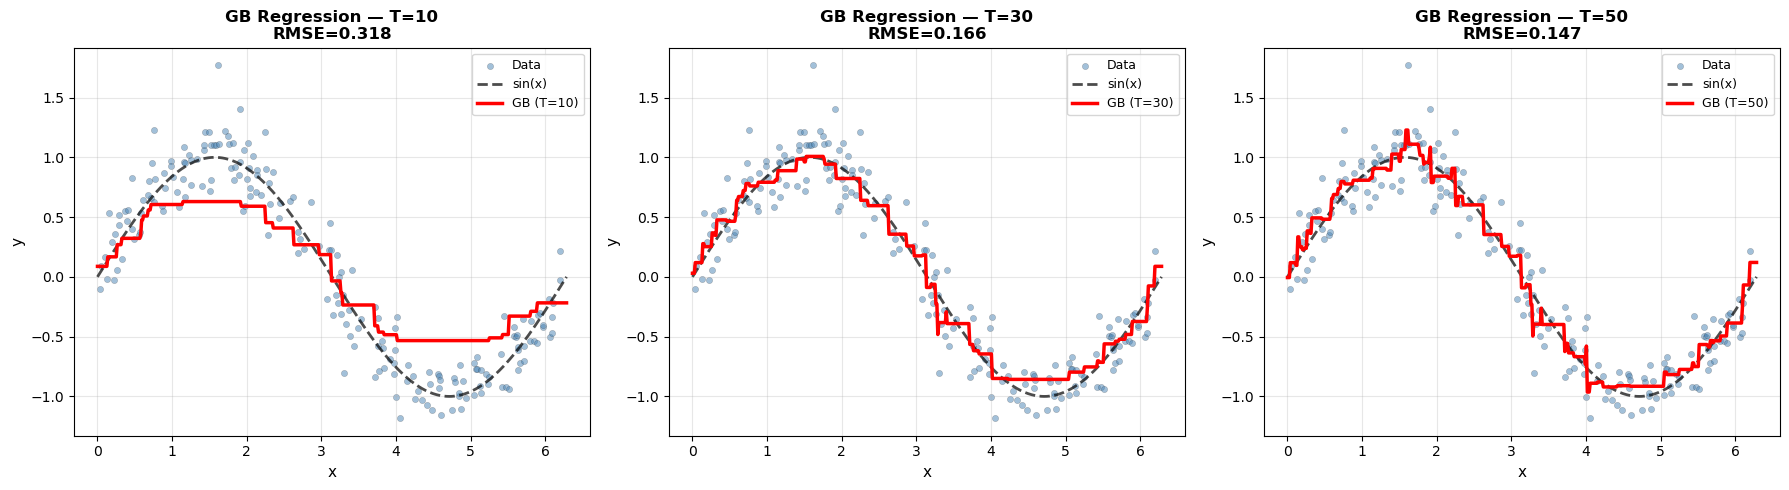

In [4]:
np.random.seed(42)
X_r = np.sort(np.random.uniform(0, 2*np.pi, 200)).reshape(-1, 1)
y_r = np.sin(X_r.ravel()) + np.random.normal(0, 0.2, 200)

X_line = np.linspace(0, 2*np.pi, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, n_est in zip(axes, [10, 30, 50]):
    gbr = GradientBoostingRegressor(n_estimators=n_est, learning_rate=0.1, max_depth=3, random_state=42)
    gbr.fit(X_r, y_r)
    y_pred_r = gbr.predict(X_line)
    
    tr_rmse = rmse(y_r, gbr.predict(X_r))
    ax.scatter(X_r, y_r, c='steelblue', s=20, alpha=0.5, edgecolors='k', lw=0.2, label='Data')
    ax.plot(X_line, np.sin(X_line), 'k--', linewidth=2, alpha=0.7, label='sin(x)')
    ax.plot(X_line, y_pred_r, 'r-', linewidth=2.5, label=f'GB (T={n_est})')
    ax.set_title(f'GB Regression — T={n_est}\nRMSE={tr_rmse:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/gradient_boosting_regression.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Gradient Boosting vs Random Forest

In [5]:
from rice_ml import RandomForestClassifier

models = [
    ('Random Forest (T=100)', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('GB (T=50, lr=0.1)', GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)),
    ('GB (T=100, lr=0.05)', GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=42)),
    ('GB (T=200, lr=0.01)', GradientBoostingClassifier(n_estimators=50, learning_rate=0.01, random_state=42)),
]

print(f"{'Model':<30} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 52)
for name, model in models:
    model.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, model.predict(X_train))
    te_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:<30} {tr_acc:>10.4f} {te_acc:>10.4f}")

Model                           Train Acc   Test Acc
----------------------------------------------------


Random Forest (T=100)              1.0000     0.9646


GB (T=50, lr=0.1)                  0.9868     0.9558


GB (T=100, lr=0.05)                0.9890     0.9558


GB (T=200, lr=0.01)                0.6272     0.6283


## Summary

| Property | Random Forest | Gradient Boosting |
|---|---|---|
| Tree building | Parallel (independent) | Sequential (dependent) |
| Bias reduction | No | Yes |
| Variance reduction | Yes | Partial (through shrinkage) |
| Overfitting risk | Low | Higher (if not tuned) |
| Key hyperparameter | n_trees, max_features | n_estimators, learning_rate, max_depth |

**Key Takeaways:**
- Gradient Boosting builds trees **sequentially** to correct residual errors
- Smaller learning rate + more trees = better generalization (shrinkage principle)
- Gradient Boosting often outperforms Random Forest with proper tuning
- XGBoost, LightGBM, and CatBoost are modern, highly optimized implementations